# LAPORAN TUGAS BESAR STATPROB
## Tugas 1: Pemahaman Data, Audit Kualitas Data & Penanganan Missing Value
**Penanggung Jawab: Dyah Indana Zulfa (NRP: 5027261079)**
*Kelompok: Day in My Anaconda | Dataset: `data/train.csv`*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan data pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Pengaturan estetika grafik matplotlib dan seaborn
plt.rcParams['figure.figsize'] = (10, 5.5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

# Palet warna konsisten untuk analisis kelompok
WARNA_UTAMA = '#2b5876'
WARNA_KEDUA = '#e74c3c'
WARNA_KETIGA = '#2ecc71'
PALET_KELOMPOK = [WARNA_UTAMA, WARNA_KEDUA, WARNA_KETIGA, '#f39c12', '#9b59b6', '#34495e']
sns.set_palette(PALET_KELOMPOK)

print("Status: Seluruh pustaka analitis berhasil dimuat.")

Status: Seluruh pustaka analitis berhasil dimuat.


---
## BAB I: PEMAHAMAN DATA, AUDIT KUALITAS DATA & PENANGANAN MISSING VALUE
**Penanggung Jawab Tugas 1: Dyah Indana Zulfa (NRP: 5027261079)**

Pada bagian ini, Dyah melakukan audit terhadap struktur data awal dari berkas `data/train.csv`. Langkah-langkah yang dilakukan mencakup:
1. Pemuatan data mentah dan pembersihan kolom index yang tidak relevan (`Unnamed: 0`).
2. Penentuan tipe data dan penyusunan taksonomi variabel secara menyeluruh (Kategorikal Nominal, Kategorikal Ordinal, Skala Rating 0–5, Numerik Diskrit/Kontinu, dan Target Biner).
3. Analisis missing value dan pengujian sifat data hilang (MCAR vs. MAR) pada `Arrival Delay in Minutes`.
4. Komparasi empiris metode imputasi keterlambatan (Median vs. Departure Delay).
5. Investigasi mendalam nilai rating 0 sebagai sinyal non-penggunaan fasilitas.
6. Evaluasi keterbatasan metode IQR pada variabel keterlambatan yang bersifat *zero-inflated*.

In [2]:
# 1. Pemuatan Data Mentah train.csv
# Menghapus kolom 'Unnamed: 0' yang merupakan index sisa saat ekspor berkas csv
train = pd.read_csv('data/train.csv').drop(columns=['Unnamed: 0'], errors='ignore')

print("=== Ringkasan Dimensi & Integritas Data ===")
print(f"Jumlah baris observasi : {train.shape[0]:,} baris")
print(f"Jumlah kolom fitur     : {train.shape[1]} kolom")
print(f"Jumlah baris duplikat  : {train.drop(columns=['id']).duplicated().sum()} baris")
print(f"Jumlah ID duplikat     : {train['id'].duplicated().sum()} ID")

# 2. Pengelompokan Kolom Berdasarkan Sifat Pengukuran
rating_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink", "Online boarding",
    "Seat comfort", "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service", "Cleanliness"
]
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]

# Membuat representasi target numerik biner (1: satisfied, 0: neutral or dissatisfied)
train["sat"] = (train["satisfaction"] == "satisfied").astype(int)

# 3. Klasifikasi Taksonomi Variabel & Kamus Data Lengkap
# Menentukan apakah variabel masuk kategori Kategorikal Nominal, Ordinal, Numerik, atau Skala Rating
kamus_data = pd.DataFrame({
    'Nama Kolom': train.columns,
    'Tipe Data Python': train.dtypes.values,
    'Skala & Sifat Pengukuran': [
        'Identifier (ID Unik)' if c == 'id' else
        'Target Analisis (Kategorikal Nominal Biner)' if c in ['satisfaction', 'sat'] else
        'Kategorikal Nominal Biner' if c in ['Gender', 'Customer Type', 'Type of Travel'] else
        'Kategorikal Ordinal Bertingkat' if c == 'Class' else
        'Skala Likert / Ordinal (Rating 0-5)' if c in rating_cols else
        'Numerik Kontinu / Rasio (Zero-Inflated)' if 'Delay' in c else
        'Numerik Diskrit / Rasio' if c == 'Age' else
        'Numerik Kontinu / Rasio' for c in train.columns
    ],
    'Rentang / Kategori Nilai': [
        f"1 s.d. {train[c].max():,}" if c == 'id' else
        "neutral or dissatisfied, satisfied" if c == 'satisfaction' else
        "0, 1" if c == 'sat' else
        str(train[c].dropna().unique().tolist()) if train[c].nunique() <= 5 else
        f"Min: {train[c].min()}, Max: {train[c].max()}" for c in train.columns
    ],
    'Catatan Analitis': [
        'Kunci primer unik, tidak digunakan sebagai prediktor' if c == 'id' else
        'Variabel target kepuasan penumpang' if c in ['satisfaction', 'sat'] else
        'Faktor demografi gender penumpang' if c == 'Gender' else
        'Status loyalitas (Loyal vs disloyal)' if c == 'Customer Type' else
        'Tujuan penerbangan (Business vs Personal)' if c == 'Type of Travel' else
        'Kelas kabin terurut: Eco < Eco Plus < Business' if c == 'Class' else
        'Skala 1-5 (buruk s.d. baik); nilai 0 = fasilitas tidak digunakan' if c in rating_cols else
        'Waktu keterlambatan dalam menit (banyak nilai 0)' if 'Delay' in c else
        'Usia penumpang dalam tahun penuh' if c == 'Age' else
        'Jarak tempuh penerbangan dalam mil/km' for c in train.columns
    ]
})
display(kamus_data)

=== Ringkasan Dimensi & Integritas Data ===
Jumlah baris observasi : 103,904 baris
Jumlah kolom fitur     : 24 kolom
Jumlah baris duplikat  : 0 baris
Jumlah ID duplikat     : 0 ID


,Nama Kolom,Tipe Data Python,Skala & Sifat Pengukuran,Rentang / Kategori Nilai,Catatan Analitis
0,id,int64,Identifier (ID Unik),"1 s.d. 129,880","Kunci primer unik, tidak digunakan sebagai pre..."
1,Gender,str,Kategorikal Nominal Biner,"['Male', 'Female']",Faktor demografi gender penumpang
2,Customer Type,str,Kategorikal Nominal Biner,"['Loyal Customer', 'disloyal Customer']",Status loyalitas (Loyal vs disloyal)
3,Age,int64,Numerik Diskrit / Rasio,"Min: 7, Max: 85",Usia penumpang dalam tahun penuh
4,Type of Travel,str,Kategorikal Nominal Biner,"['Personal Travel', 'Business travel']",Tujuan penerbangan (Business vs Personal)
5,Class,str,Kategorikal Ordinal Bertingkat,"['Eco Plus', 'Business', 'Eco']",Kelas kabin terurut: Eco < Eco Plus < Business
6,Flight Distance,int64,Numerik Kontinu / Rasio,"Min: 31, Max: 4983",Jarak tempuh penerbangan dalam mil/km
7,Inflight wifi service,int64,Skala Likert / Ordinal (Rating 0-5),"Min: 0, Max: 5",Skala 1-5 (buruk s.d. baik); nilai 0 = fasilit...
8,Departure/Arrival time convenient,int64,Skala Likert / Ordinal (Rating 0-5),"Min: 0, Max: 5",Skala 1-5 (buruk s.d. baik); nilai 0 = fasilit...
9,Ease of Online booking,int64,Skala Likert / Ordinal (Rating 0-5),"Min: 0, Max: 5",Skala 1-5 (buruk s.d. baik); nilai 0 = fasilit...


### 1.2 Analisis Nilai Hilang (*Missing Value*): Uji Sifat MCAR vs. MAR
Pemeriksaan awal menunjukkan bahwa dari 24 kolom yang ada, hanya kolom `Arrival Delay in Minutes` yang memiliki nilai hilang, yaitu sebanyak 310 baris (0,30% dari total data).

Untuk menentukan metode penanganan yang tepat, Dyah menguji apakah data hilang ini terjadi secara acak murni (*Missing Completely at Random* / MCAR) ataukah berkaitan dengan variabel lain (*Missing at Random* / MAR). Kami membandingkan nilai `Departure Delay in Minutes` antara data yang memiliki nilai `Arrival Delay` lengkap dengan data yang nilai `Arrival Delay`-nya hilang.

Variabel dengan nilai hilang:
Arrival Delay in Minutes    310
dtype: int64

Statistik Departure Delay saat data Arrival Delay HILANG (n = 310):


count    310.00
mean      37.43
50%        8.00
std       62.24
max      455.00
Name: Departure Delay in Minutes, dtype: float64

Statistik Departure Delay saat data Arrival Delay LENGKAP (n = 103.594):


count    103594.00
mean         14.75
50%           0.00
std          38.12
max        1592.00
Name: Departure Delay in Minutes, dtype: float64

Mean Absolute Error (MAE) jika diisi Median           : 15.18 menit
Mean Absolute Error (MAE) jika diisi Departure Delay  : 4.97 menit


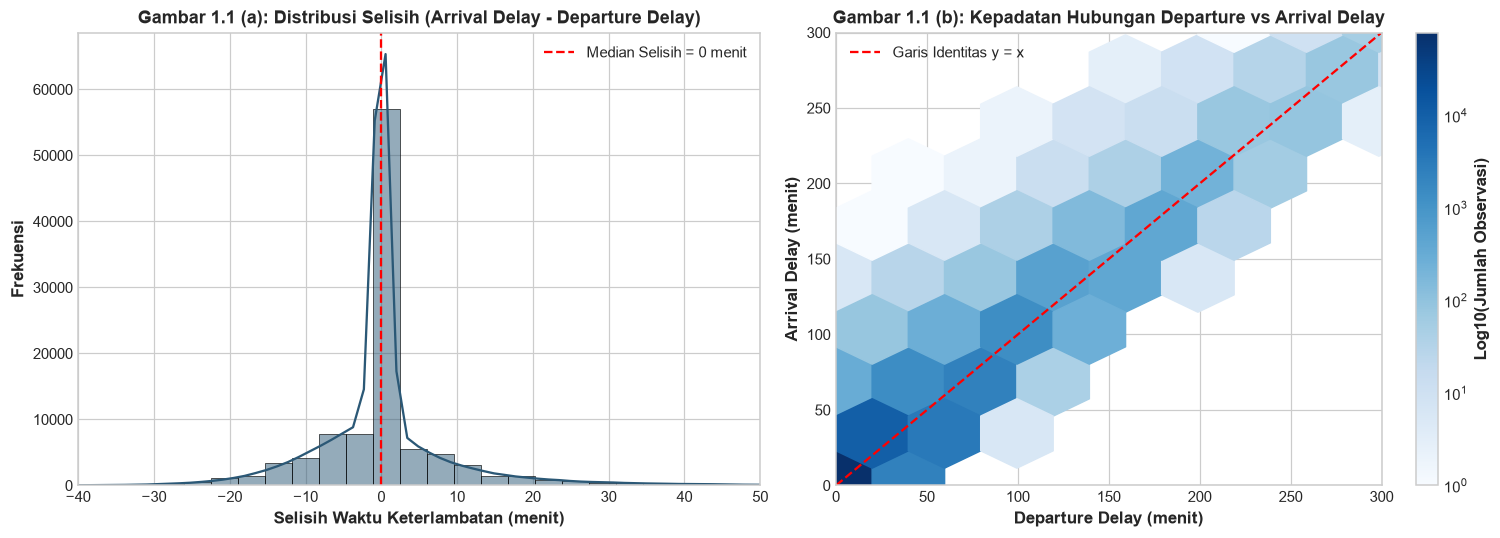

In [3]:
# Pemeriksaan data hilang pada setiap kolom
missing_series = train.isna().sum()[lambda s: s > 0]
print("Variabel dengan nilai hilang:")
print(missing_series)

# Uji perbandingan: Nilai Departure Delay saat Arrival Delay hilang vs lengkap
is_missing = train["Arrival Delay in Minutes"].isna()
print("\nStatistik Departure Delay saat data Arrival Delay HILANG (n = 310):")
display(train.loc[is_missing, "Departure Delay in Minutes"].describe()[['count', 'mean', '50%', 'std', 'max']].round(2))

print("Statistik Departure Delay saat data Arrival Delay LENGKAP (n = 103.594):")
display(train.loc[~is_missing, "Departure Delay in Minutes"].describe()[['count', 'mean', '50%', 'std', 'max']].round(2))

# Komparasi Empiris: Imputasi Median vs Imputasi Nilai Departure Delay
data_lengkap = train.dropna(subset=["Arrival Delay in Minutes"])
nilai_aktual = data_lengkap["Arrival Delay in Minutes"]
nilai_departure = data_lengkap["Departure Delay in Minutes"]

galat_median = np.abs(nilai_aktual - nilai_aktual.median()).mean()
galat_departure = np.abs(nilai_aktual - nilai_departure).mean()

print(f"Mean Absolute Error (MAE) jika diisi Median           : {galat_median:.2f} menit")
print(f"Mean Absolute Error (MAE) jika diisi Departure Delay  : {galat_departure:.2f} menit")

# Gambar 1.1: Visualisasi Distribusi Selisih Delay dan Korelasi Hexbin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi selisih antara Arrival Delay dan Departure Delay
selisih_delay = nilai_aktual - nilai_departure
sns.histplot(selisih_delay, bins=80, kde=True, color=WARNA_UTAMA, ax=axes[0])
axes[0].set_xlim(-40, 50)
axes[0].set_title("Gambar 1.1 (a): Distribusi Selisih (Arrival Delay - Departure Delay)")
axes[0].set_xlabel("Selisih Waktu Keterlambatan (menit)")
axes[0].set_ylabel("Frekuensi")
axes[0].axvline(0, color='red', linestyle='--', label='Median Selisih = 0 menit')
axes[0].legend()

# Plot 2: Hexbin plot korelasi keberangkatan dan kedatangan
hb = axes[1].hexbin(nilai_departure, nilai_aktual, gridsize=40, cmap='Blues', mincnt=1, bins='log')
axes[1].plot([0, 300], [0, 300], 'r--', label='Garis Identitas y = x')
axes[1].set_xlim(0, 300)
axes[1].set_ylim(0, 300)
axes[1].set_title("Gambar 1.1 (b): Kepadatan Hubungan Departure vs Arrival Delay")
axes[1].set_xlabel("Departure Delay (menit)")
axes[1].set_ylabel("Arrival Delay (menit)")
axes[1].legend()
cb = fig.colorbar(hb, ax=axes[1])
cb.set_label('Log10(Jumlah Observasi)')

plt.tight_layout()
plt.show()

### 1.3 Investigasi Nilai Rating 0: Mengapa Tidak Boleh Dihapus atau Diimputasi?
Pada kuesioner berskala 1 sampai 5, nilai 0 sering disalahartikan sebagai data yang tidak valid. Namun, setelah Dyah memeriksa korelasi nilai 0 terhadap target kepuasan, ditemukan bahwa **penumpang yang memberi nilai 0 pada fasilitas wifi memiliki kepuasan 99,7%**.

Hal ini mengindikasikan bahwa nilai 0 menandakan penumpang yang tidak menggunakan fasilitas tersebut (misalnya tidak membeli akses wifi di pesawat). Karena membawa informasi perilaku yang sangat spesifik, nilai 0 tidak boleh diubah menjadi nilai rata-rata atau NaN.

,Layanan,Frekuensi Nilai 0,Persentase terhadap Total,Tingkat Kepuasan saat Rating 0 (%)
1,Departure/Arrival time convenient,5300,5.10,47.5
2,Ease of Online booking,4487,4.32,66.4
0,Inflight wifi service,3103,2.99,99.7
5,Online boarding,2428,2.34,55.6
9,Leg room service,472,0.45,35.2
4,Food and drink,107,0.10,46.7
7,Inflight entertainment,14,0.01,0.0
12,Cleanliness,12,0.01,0.0
11,Inflight service,3,0.00,0.0
8,On-board service,3,0.00,0.0


Tingkat kepuasan penumpang dengan >= 3 rating bernilai 0 : 88.2% (n = 2,614)
Tingkat kepuasan penumpang tanpa ada rating bernilai 0   : 42.6% (n = 95,704)


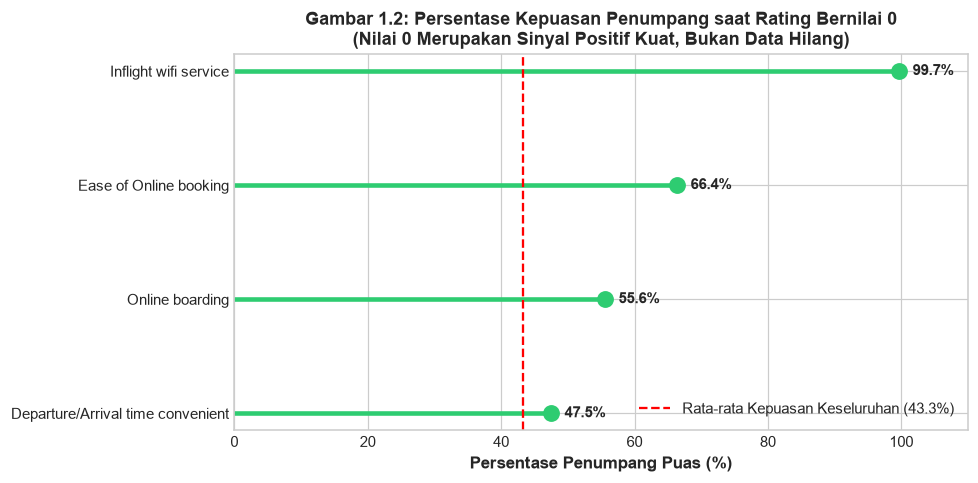

In [4]:
# Menghitung frekuensi nilai 0 dan tingkat kepuasan pada tiap layanan
rekap_nol = []
for c in rating_cols:
    jumlah_0 = (train[c] == 0).sum()
    if jumlah_0 > 0:
        kepuasan_0 = train[train[c] == 0]["sat"].mean() * 100
        rekap_nol.append({
            'Layanan': c,
            'Frekuensi Nilai 0': jumlah_0,
            'Persentase terhadap Total': round((jumlah_0 / len(train)) * 100, 2),
            'Tingkat Kepuasan saat Rating 0 (%)': round(kepuasan_0, 1)
        })

df_rekap_nol = pd.DataFrame(rekap_nol).sort_values(by='Frekuensi Nilai 0', ascending=False)
display(df_rekap_nol)

# Pemeriksaan penumpang dengan banyak nilai rating 0
train["banyak_nol"] = train[rating_cols].eq(0).sum(axis=1)
puas_multi_nol = train[train["banyak_nol"] >= 3]["sat"].mean() * 100
puas_tanpa_nol = train[train["banyak_nol"] == 0]["sat"].mean() * 100
print(f"Tingkat kepuasan penumpang dengan >= 3 rating bernilai 0 : {puas_multi_nol:.1f}% (n = {train['banyak_nol'].ge(3).sum():,})")
print(f"Tingkat kepuasan penumpang tanpa ada rating bernilai 0   : {puas_tanpa_nol:.1f}% (n = {train['banyak_nol'].eq(0).sum():,})")

# Gambar 1.2: Lollipop Chart Kepuasan saat Rating = 0
top_nol = df_rekap_nol.head(4).sort_values(by='Tingkat Kepuasan saat Rating 0 (%)')
plt.figure(figsize=(9, 4.5))
plt.hlines(y=top_nol['Layanan'], xmin=0, xmax=top_nol['Tingkat Kepuasan saat Rating 0 (%)'], color=WARNA_KETIGA, lw=3)
plt.plot(top_nol['Tingkat Kepuasan saat Rating 0 (%)'], top_nol['Layanan'], "o", markersize=10, color=WARNA_KETIGA)
plt.axvline(train['sat'].mean()*100, color='red', linestyle='--', label=f"Rata-rata Kepuasan Keseluruhan ({train['sat'].mean()*100:.1f}%)")
plt.title("Gambar 1.2: Persentase Kepuasan Penumpang saat Rating Bernilai 0\n(Nilai 0 Merupakan Sinyal Positif Kuat, Bukan Data Hilang)")
plt.xlabel("Persentase Penumpang Puas (%)")
plt.xlim(0, 110)
for _, r in top_nol.iterrows():
    plt.text(r['Tingkat Kepuasan saat Rating 0 (%)'] + 2, r['Layanan'], f"{r['Tingkat Kepuasan saat Rating 0 (%)']:.1f}%", va='center', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 1.4 Evaluasi Nilai Ekstrem & Distorsi Batas IQR pada Variabel Keterlambatan
Dyah mengevaluasi sebaran variabel numerik (`Age`, `Flight Distance`, `Departure Delay`, `Arrival Delay`). Data keterlambatan penerbangan memiliki karakteristik *zero-inflated* (lebih dari 56% bernilai 0). 

Rumus baku Tukey ($Q_3 + 1,5 \times \text{IQR}$) keliru menandai 13% hingga 14% observasi keterlambatan sebagai pencilan (*outlier*). Padahal keterlambatan hingga beberapa jam adalah kejadian operasional yang nyata, bukan kesalahan entri data.

,min,25%,50%,75%,max,Kemencengan (Skewness),Keruncingan (Kurtosis)
Age,7.0,27.0,40.0,51.0,85.0,-0.00,-0.72
Flight Distance,31.0,414.0,843.0,1743.0,4983.0,1.11,0.27
Departure Delay in Minutes,0.0,0.0,0.0,12.0,1592.0,6.73,100.27
Arrival Delay in Minutes,0.0,0.0,0.0,13.0,1584.0,6.60,94.54


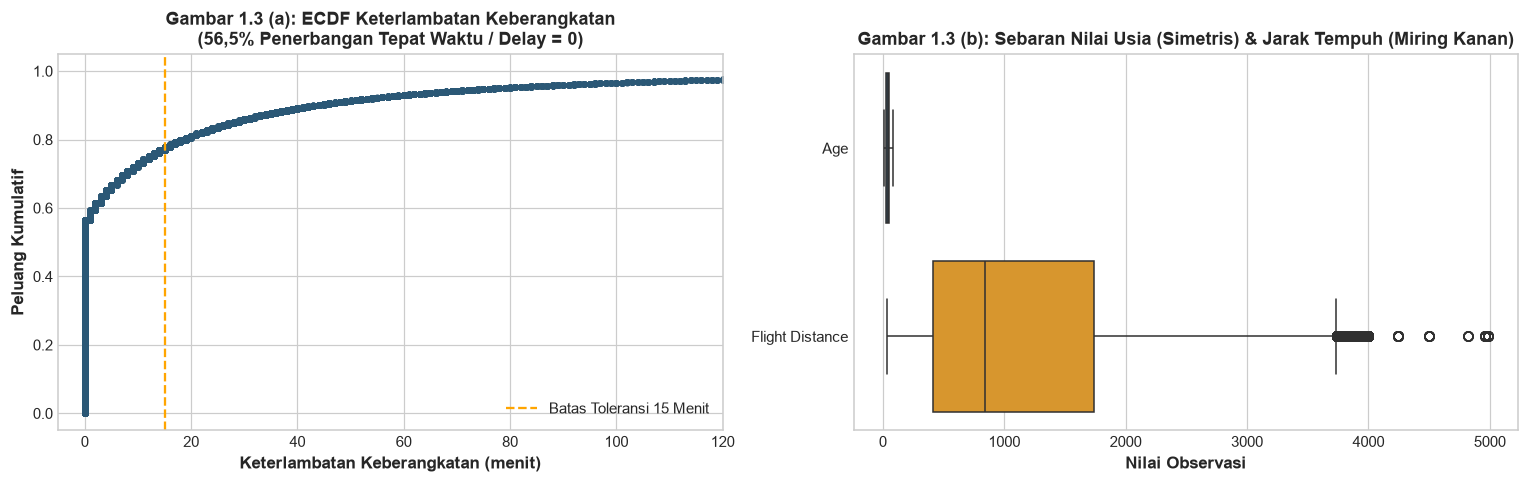

In [5]:
# Statistik Deskriptif Variabel Numerik
statistik_num = train[num_cols].describe().T
statistik_num['Kemencengan (Skewness)'] = train[num_cols].skew()
statistik_num['Keruncingan (Kurtosis)'] = train[num_cols].kurtosis()
display(statistik_num[['min', '25%', '50%', '75%', 'max', 'Kemencengan (Skewness)', 'Keruncingan (Kurtosis)']].round(2))

# Gambar 1.3: ECDF Keterlambatan & Boxplot Variabel Numerik
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Kurva Probabilitas Kumulatif Empiris (ECDF) Departure Delay
delay_terurut = np.sort(train['Departure Delay in Minutes'])
ecdf_y = np.arange(1, len(delay_terurut) + 1) / len(delay_terurut)
axes[0].plot(delay_terurut, ecdf_y, marker='.', linestyle='none', color=WARNA_UTAMA)
axes[0].set_xlim(-5, 120)
axes[0].set_title("Gambar 1.3 (a): ECDF Keterlambatan Keberangkatan\n(56,5% Penerbangan Tepat Waktu / Delay = 0)")
axes[0].set_xlabel("Keterlambatan Keberangkatan (menit)")
axes[0].set_ylabel("Peluang Kumulatif")
axes[0].axvline(15, color='orange', linestyle='--', label='Batas Toleransi 15 Menit')
axes[0].legend()

# Plot 2: Boxplot Horizontal Usia dan Jarak Penerbangan
sns.boxplot(data=train[['Age', 'Flight Distance']], orient='h', palette=[WARNA_UTAMA, '#f39c12'], ax=axes[1])
axes[1].set_title("Gambar 1.3 (b): Sebaran Nilai Usia (Simetris) & Jarak Tempuh (Miring Kanan)")
axes[1].set_xlabel("Nilai Observasi")

plt.tight_layout()
plt.show()